# 05 — Walk-Forward Validation
Tune on a rolling train window, evaluate frozen parameters on the next year.
The IS→OOS decay table is the honest measure of how much of notebook 04's
performance is real vs overfit.

### Walk-forward validation
Train on years 1–4, test on year 5 OOS. Repeat rolling window. Reveals overfitting.


In [1]:
import sys
sys.path.insert(0, "../src")
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.width", 160)

### IS vs OOS decay
In-sample inflated, out-of-sample honest. Big gap = overfit or market changed.


In [2]:
from lab.backtest import StrategyConfig
from lab.experiments import walk_forward

base = StrategyConfig.from_yaml("../configs/short_put_45dte.yaml")
grid = {
    "leg1_delta.target": [0.10, 0.16, 0.30],
    "take_profit":       [0.25, 0.5, None],
}
wf = walk_forward(base, grid, train_years=4, test_years=1,
                  first_year=2010, last_year=2023)
wf.windows.round(3)

f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning: divide by zero encountered in scalar divide
  return np.abs(np.percentile(returns, 95)) / np.abs(np.percentile(returns, 5))
f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning: invalid value encountered in scalar divide
  return np.abs(np.percentile(returns, 95)) / np.abs(np.percentile(returns, 5))
f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning: divide by zero encountered in scalar divide
  return np.abs(np.percentile(returns, 95)) / np.abs(np.percentile(returns, 5))
f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning: divide by zero encountered in scalar divide
  return np.abs(np.percentile(returns, 95)) / np.abs(np.percentile(returns, 5))
f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning: 

,train,test,best_params,is_sharpe_ratio,is_n_trades,oos_total_trades,oos_win_rate,oos_total_return,oos_max_drawdown,oos_sharpe_ratio
0,2010-2013,2014,"{""leg1_delta.target"": 0.16, ""take_profit"": 0.25}",1.360,230.0,62,0.919,0.075,-0.022,1.355
1,2011-2014,2015,"{""leg1_delta.target"": 0.16, ""take_profit"": 0.25}",1.460,234.0,63,0.905,0.064,-0.051,0.743
2,2012-2015,2016,"{""leg1_delta.target"": 0.16, ""take_profit"": 0.25}",1.368,255.0,62,0.903,0.107,-0.027,1.419
3,2013-2016,2017,"{""leg1_delta.target"": 0.3, ""take_profit"": 0.25}",1.330,215.0,55,0.964,0.226,-0.023,4.374
4,2014-2017,2018,"{""leg1_delta.target"": 0.3, ""take_profit"": 0.25}",1.474,206.0,63,0.810,-0.321,-0.378,-0.984
5,2015-2018,2019,"{""leg1_delta.target"": 0.16, ""take_profit"": null}",0.575,122.0,40,0.800,0.105,-0.053,1.028
6,2016-2019,2020,"{""leg1_delta.target"": 0.16, ""take_profit"": 0.25}",0.926,255.0,78,0.910,0.029,-0.447,0.230
7,2017-2020,2021,"{""leg1_delta.target"": 0.16, ""take_profit"": 0.25}",0.405,273.0,66,0.955,0.405,-0.047,3.631
8,2018-2021,2022,"{""leg1_delta.target"": 0.16, ""take_profit"": 0.25}",0.577,276.0,63,0.825,-0.065,-0.214,-0.124
9,2019-2022,2023,"{""leg1_delta.target"": 0.16, ""take_profit"": 0.25}",0.701,268.0,67,0.925,0.246,-0.073,1.761


### OOS equity curve
Stitch test windows into one curve. Most realistic return estimate.


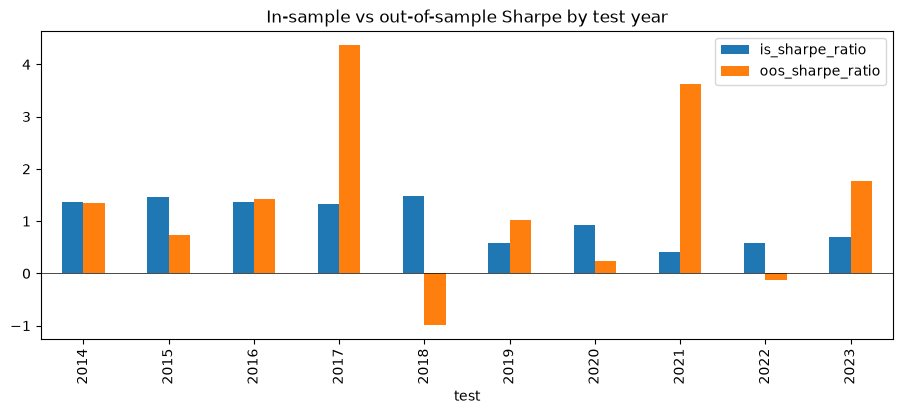

In [3]:
ax = wf.windows.set_index("test")[["is_sharpe_ratio", "oos_sharpe_ratio"]].plot.bar(
    title="In-sample vs out-of-sample Sharpe by test year")
ax.axhline(0, color="k", lw=0.5);

### Parameter stability
Same params chosen each year? = stable edge. Flipping = fragile.


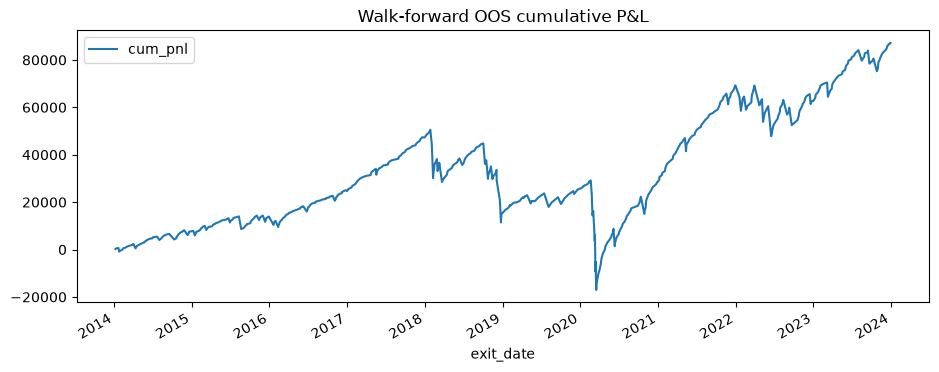

In [4]:
# Stitched OOS equity: performance using only parameters chosen on past data
oos = wf.oos_trades.sort_values("exit_date")
oos["cum_pnl"] = oos["realized_pnl"].cumsum()
oos.plot(x="exit_date", y="cum_pnl", title="Walk-forward OOS cumulative P&L");

In [5]:
print("Chosen parameters per window (stability check):")
wf.windows[["train", "test", "best_params"]]

Chosen parameters per window (stability check):


,train,test,best_params
0,2010-2013,2014,"{""leg1_delta.target"": 0.16, ""take_profit"": 0.25}"
1,2011-2014,2015,"{""leg1_delta.target"": 0.16, ""take_profit"": 0.25}"
2,2012-2015,2016,"{""leg1_delta.target"": 0.16, ""take_profit"": 0.25}"
3,2013-2016,2017,"{""leg1_delta.target"": 0.3, ""take_profit"": 0.25}"
4,2014-2017,2018,"{""leg1_delta.target"": 0.3, ""take_profit"": 0.25}"
5,2015-2018,2019,"{""leg1_delta.target"": 0.16, ""take_profit"": null}"
6,2016-2019,2020,"{""leg1_delta.target"": 0.16, ""take_profit"": 0.25}"
7,2017-2020,2021,"{""leg1_delta.target"": 0.16, ""take_profit"": 0.25}"
8,2018-2021,2022,"{""leg1_delta.target"": 0.16, ""take_profit"": 0.25}"
9,2019-2022,2023,"{""leg1_delta.target"": 0.16, ""take_profit"": 0.25}"
